### Script to get PCA and make biplot (comparing to spectral indices and agronomic variables)

In [12]:
# imports
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Load data
df = pd.read_csv('/Users/zhalem/Documents/ASD_data/PANGEOS_NO_2025/csv_exports/corrected_data_h20removed_6only.csv')

y = df['class']
spectrum_names = df['spectrumname']

# Select spectral columns only
X_df = df.loc[:, '350':'2400'].copy()
wavelengths_all = X_df.columns.astype(float)

In [13]:
# Remove noisy water bands
water_mask = (
    ((wavelengths_all >= 1350) & (wavelengths_all <= 1460)) |
    ((wavelengths_all >= 1790) & (wavelengths_all <= 1970))
)
X_df = X_df.loc[:, ~water_mask]
X_scaled = StandardScaler().fit_transform(X_df.values)


In [14]:
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Build PCA dataframe
pca_df = pd.DataFrame({
    'PC1': X_pca[:,0],
    'PC2': X_pca[:,1],
    'class': y.values,
    'spectrumname': spectrum_names.values
})

In [15]:
# List all plot codes individually with their cultivar
plot_to_cultivar = {
    1207: 'Helmi', 1405: 'Helmi', 1508: 'Helmi', 1810: 'Helmi',
    1210: 'Bjarne', 1310: 'Bjarne', 1606: 'Bjarne', 1807: 'Bjarne',
    1108: 'Demonstrant', 1304: 'Demonstrant', 1601: 'Demonstrant', 1807: 'Demonstrant',
    1208: 'Isak', 1409: 'Isak', 1602: 'Isak', 1706: 'Isak',
    1402: 'Mirakel', 1504: 'Mirakel', 1707: 'Mirakel', 1704:'Bjarne',
    1103: 'Zebra', 1305: 'Zebra', 1502: 'Zebra', 1701: 'Zebra'
}

In [16]:
# for individual spectra
def extract_plotcode(name):
    import re
    match = re.search(r'plot_(\d+)_\d+', name)
    if match:
        return int(match.group(1))
    else:
        return np.nan

pca_df['plotcode'] = pca_df['spectrumname'].apply(extract_plotcode)
pca_df['cultivar'] = pca_df['plotcode'].map(plot_to_cultivar)

In [17]:
# for the mean of each plot
import re

def extract_plotcode(spectrumname):
    """
    Extracts the numeric plot code from a spectrumname ending with '_mean'.
    
    Example:
        '1207_mean' -> 1207
        '1103_mean' -> 1103
    """
    match = re.search(r'(\d+)_mean', spectrumname)
    if match:
        return int(match.group(1))
    else:
        return None  # or np.nan if you prefer
pca_df['plotcode'] = pca_df['spectrumname'].apply(extract_plotcode)
pca_df['cultivar'] = pca_df['plotcode'].map(plot_to_cultivar)

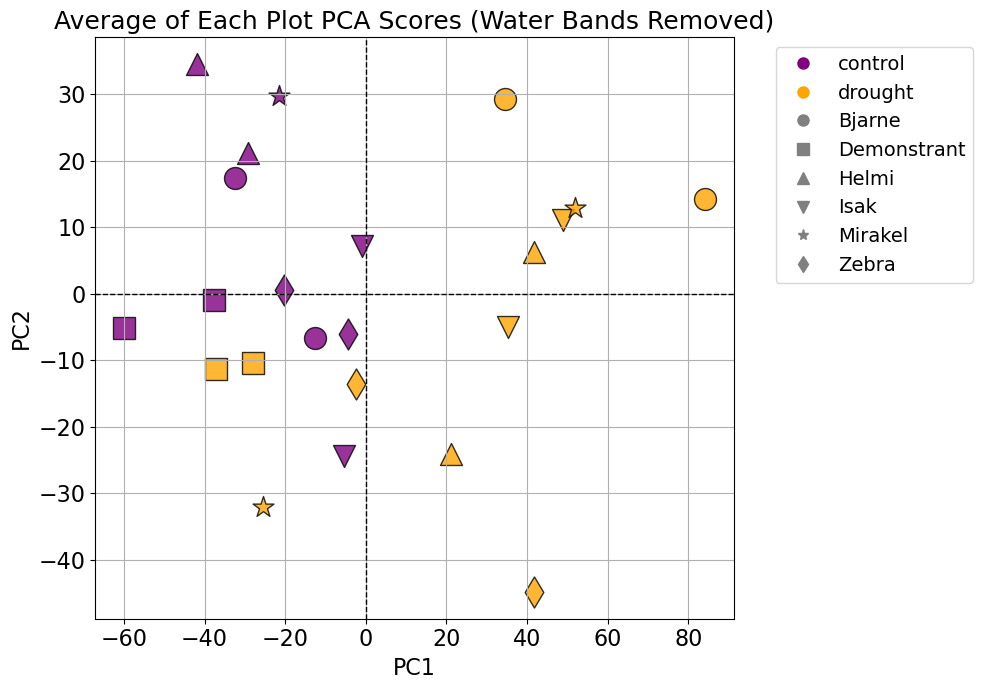

In [18]:
# PCA plot
color_dict = {'control':'purple', 'drought':'orange'}
markers = ['o','s','^','v','*','d']
unique_cultivars = sorted(pca_df['cultivar'].dropna().unique())
marker_dict = {cultivar: markers[i % len(markers)] for i, cultivar in enumerate(unique_cultivars)}

plt.figure(figsize=(10,7))
for cls in pca_df['class'].unique():
    subset_cls = pca_df[pca_df['class']==cls]
    for cultivar in unique_cultivars:
        subset_cult = subset_cls[subset_cls['cultivar']==cultivar]
        plt.scatter(
            subset_cult['PC1'],
            subset_cult['PC2'],
            marker=marker_dict[cultivar],
            facecolors=color_dict[cls],
            edgecolors='k',
            s=250,
            alpha=0.8
        )

# Legends
color_legend = [Line2D([0],[0], marker='o', color='w', label=cls,
                       markerfacecolor=color_dict[cls], markersize=10)
                for cls in color_dict]
marker_legend = [Line2D([0],[0], marker=marker_dict[cult], color='gray', label=cult,
                        markerfacecolor='gray', markersize=8, linestyle='')
                 for cult in unique_cultivars]

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.tick_params(axis='both', which='major', labelsize=16)
plt.legend(handles=color_legend + marker_legend, bbox_to_anchor=(1.05,1), loc='upper left', fontsize=14)
plt.xlabel('PC1', fontsize=16)
plt.ylabel('PC2', fontsize=16)
plt.title('Average of Each Plot PCA Scores (Water Bands Removed)', fontsize=18)
plt.grid(True)

plt.tight_layout()

# Save figure to a file
plt.savefig(
    '/Users/zhalem/Documents/ASD_data/PANGEOS_NO_2025/plots/PCA_avg.png',  # file path
    dpi=300,      # resolution
    bbox_inches='tight'  # trims extra whitespace
)

plt.show()

### Create the PC table

In [19]:
pc_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pc_df['class'] = y
print(pc_df.head())

# Print % variance explained by each PC
variance_ratio = pca.explained_variance_ratio_  # array of length n_components
for i, var in enumerate(variance_ratio, start=1):
    print(f"PC{i}: {var*100:.2f}% of variance explained")

# Include variance explained in a summary table
variance_df = pd.DataFrame({
    'PC': [f'PC{i}' for i in range(1, len(variance_ratio)+1)],
    'Variance_Explained (%)': variance_ratio * 100
})
print(variance_df)

         PC1        PC2    class
0 -29.128440  21.185839  control
1  21.173774 -24.015687  drought
2  41.801559   6.321866  drought
3 -41.754614  34.540823  control
4 -12.530282  -6.680931  control
PC1: 76.79% of variance explained
PC2: 22.34% of variance explained
    PC  Variance_Explained (%)
0  PC1               76.789462
1  PC2               22.337552


### PCA Loadings

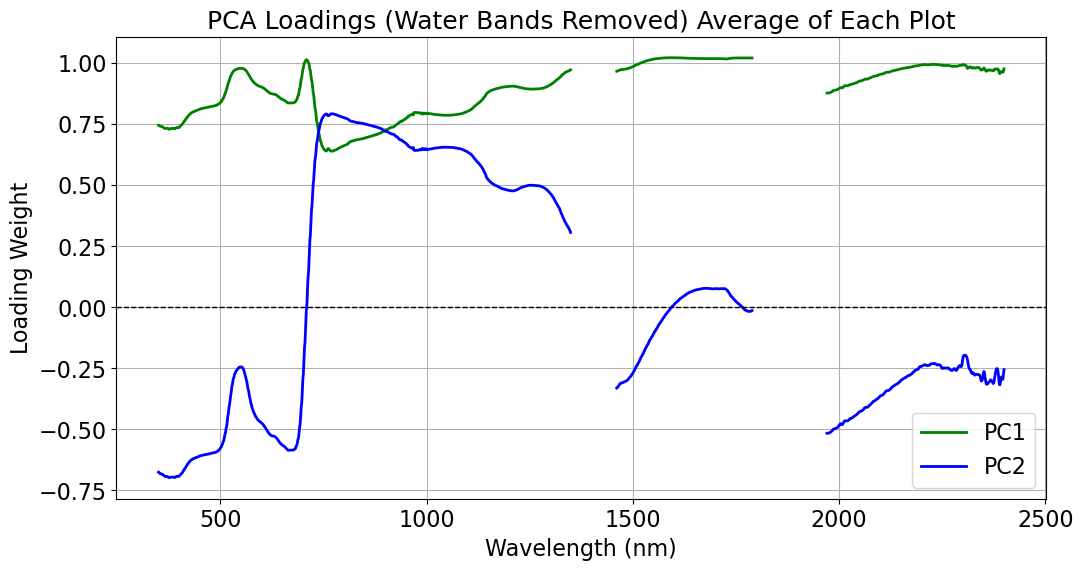

In [20]:
# plot the mean of each class
color_dict = {'PC1':'green', 'PC2':'blue'}

# Extract spectral columns only
X_df = df.loc[:, '350':'2400']

# Convert column names to float wavelengths
wavelengths_all = X_df.columns.astype(float)

# Remove water absorption regions
water_mask = (
    ((wavelengths_all >= 1350) & (wavelengths_all <= 1460)) |
    ((wavelengths_all >= 1790) & (wavelengths_all <= 1970))
)

# Keep only non-waterband wavelengths
X_df_nonwater = X_df.loc[:, ~water_mask]
wavelengths_nonwater = wavelengths_all[~water_mask]

# Standardize spectra (ignore NaNs)
X_mean = np.nanmean(X_df_nonwater.values, axis=0)
X_std = np.nanstd(X_df_nonwater.values, axis=0)
X_scaled = (X_df_nonwater.values - X_mean) / X_std


# PCA
pca = PCA(n_components=2)  # only first 2 PCs
X_pca = pca.fit_transform(X_scaled)

# Loadings: correlation-like values
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# Create full array with NaNs for water bands
loadings_full = np.full((len(wavelengths_all), loadings.shape[1]), np.nan)
loadings_full[~water_mask, :] = loadings


# Plot PCA loadings (PC1 and PC2 only)
plt.figure(figsize=(12,6))
for i in range(2):  # PC1, PC2
    pc_label = f'PC{i+1}'
    plt.plot(wavelengths_all, loadings_full[:, i], label=f'PC{i+1}', linewidth=2, color=color_dict.get(pc_label, 'gray'))

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.tick_params(axis='both', which='major', labelsize=16)
plt.xlabel('Wavelength (nm)', fontsize=16)
plt.ylabel('Loading Weight',  fontsize=16)
plt.title('PCA Loadings (Water Bands Removed) Average of Each Plot', fontsize=18)
plt.legend(fontsize=16)
plt.grid(True)

# Save figure to a file
plt.savefig(
    '/Users/zhalem/Documents/ASD_data/PANGEOS_NO_2025/plots/PCA_loadings_avg.png',  # file path
    dpi=300,      # resolution
    bbox_inches='tight'  # trims extra whitespace
)
plt.show()


### PCA Biplot with spectral indices (NDVI, NDWI, WI, WBI, MSI, NMDI) and agronomic data (NPQ, QY and Yield)

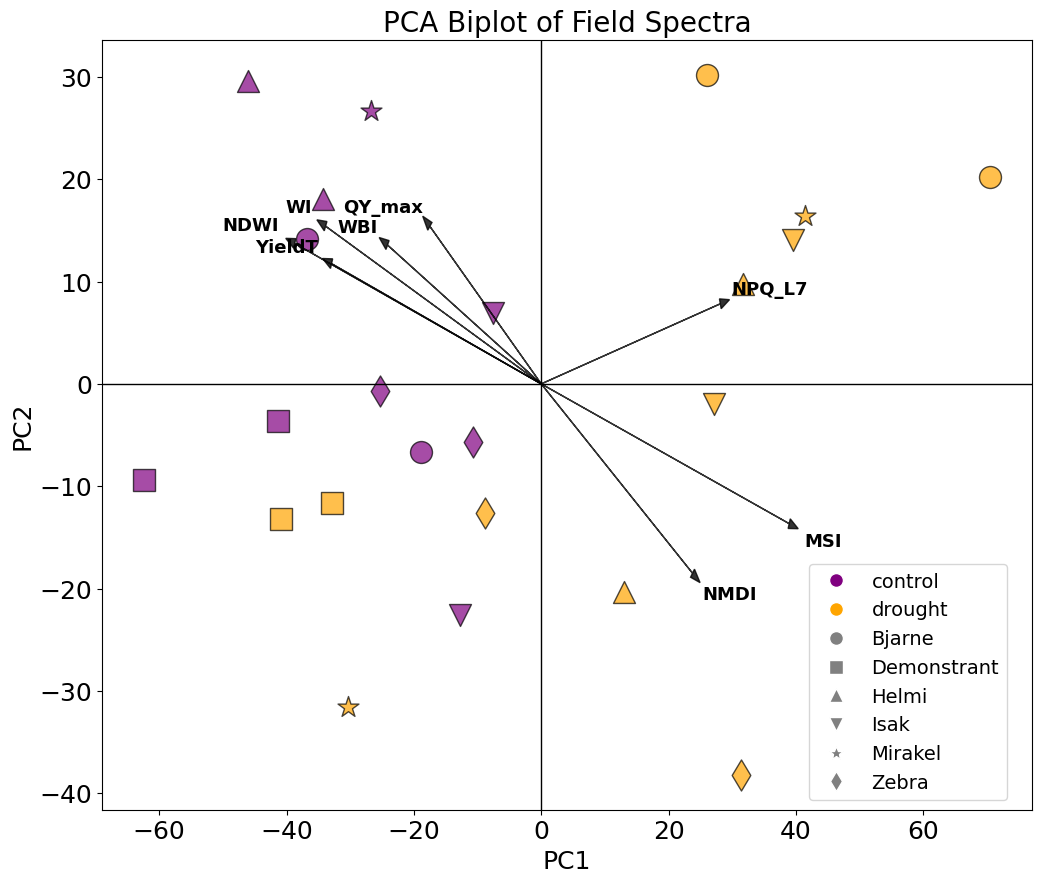

In [21]:
# Load data (already has PC1/PC2)
df = pd.read_csv('/Users/zhalem/Documents/ASD_data/PANGEOS_NO_2025/csv_exports/pca_byplot_h20removed_input.csv')

# Define colors for control vs drought
color_dict = {'control': 'purple', 'drought': 'orange'}

xvars = ['NDWI', 'WI', 'WBI', 'MSI', 'NMDI', 'QY_max', 'NPQ_L7', 'YieldT']

# Map spectrum codes to cultivar

df['spectrumcode'] = df['spectrumname'].str.extract(r'(\d+)_mean')[0].astype(int)


df['cultivar'] = df['spectrumcode'].map(plot_to_cultivar)

# Assign unique markers for each cultivar
markers = ['o','s','^','v','*','d']
unique_cultivars = sorted(df['cultivar'].dropna().unique())
marker_dict = {cultivar: markers[i % len(markers)] for i, cultivar in enumerate(unique_cultivars)}

# Plot PCA points with cultivar markers and treatment colors
fig, ax = plt.subplots(figsize=(12,10))

for cls in df['class'].unique():
    subset_cls = df[df['class'] == cls]
    for cultivar in subset_cls['cultivar'].unique():
        subset_cult = subset_cls[subset_cls['cultivar'] == cultivar]
        ax.scatter(
            subset_cult['PC1'],
            subset_cult['PC2'],
            marker=marker_dict[cultivar],
            color=color_dict[cls],
            s=250,
            alpha=0.7,
            edgecolors='k',
            label=f"{cultivar}"  # only cultivar names
        )
        
# Add variable arrows (loadings via correlation with PC1/PC2)
for var in xvars:
    corr_x = df[var].corr(df['PC1'])
    corr_y = df[var].corr(df['PC2'])
    ax.arrow(0, 0, corr_x * df['PC1'].max() * 0.8, corr_y * df['PC2'].max() * 0.8,
             color='black', alpha=0.8, head_width=1)
    
    ha = 'left' if corr_x > 0 else 'right'
    va = 'bottom' if corr_y > 0 else 'top'
    
    ax.text(corr_x * df['PC1'].max() * 0.85,
            corr_y * df['PC2'].max() * 0.85,
            var,
            ha=ha,
            va=va,
            color='black',
            fontsize=13,
            fontweight='bold')


# Styling the labels
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.axvline(0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('PC1', fontsize=18)
ax.set_ylabel('PC2', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.set_title('PCA Biplot of Field Spectra', fontsize=20)

# Legends
marker_legend = [Line2D([0],[0], marker=marker_dict[cult], color='w', label=cult,
                        markerfacecolor='gray', markersize=10, linestyle='') 
                 for cult in unique_cultivars]
color_legend = [Line2D([0],[0], marker='o', color='w', label=cls,
                       markerfacecolor=color_dict[cls], markersize=10) 
                for cls in color_dict]

ax.legend(handles=color_legend + marker_legend, bbox_to_anchor=(0.75,0), loc='lower left', fontsize=14)
plt.savefig("C:/Users/zhalem/Documents/ASD_data/PANGEOS_NO_2025/plots/pca_biplot_updated.png", dpi=300, bbox_inches="tight")  # save image
plt.show()